In [3]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import polars as pl
import os


default_path = os.getcwd()
default_path

'/home/drew/Split-Learning/PreProcessing'

In [5]:
# Obtain the file path of the directory 'Split-Learning'
while not os.getcwd().endswith('Split-Learning'):
    os.chdir('..')
    if len(os.getcwd()) == 1:
        print("Unable to find the root directory")
        break
users_default_path = os.getcwd()
users_default_path

'/home/drew/Split-Learning'

In [6]:
# Directories of MIMIC III
mimic_III = os.path.join(os.path.join(users_default_path,'physionet.org'),'files')
mimic_III = os.path.join(mimic_III,'mimiciii')
mimic_III = os.path.join(mimic_III,'1.4')
files = os.listdir(mimic_III)
os.chdir(path = mimic_III)
mimic_III

'/home/drew/Split-Learning/physionet.org/files/mimiciii/1.4'

In [7]:
files.remove('CHARTEVENTS.csv.gz')
files.remove('NOTEEVENTS.csv.gz')

In [8]:
files = [item for item in files if item.endswith('.csv.gz')]
files

['MICROBIOLOGYEVENTS.csv.gz',
 'DRGCODES.csv.gz',
 'PATIENTS.csv.gz',
 'D_ITEMS.csv.gz',
 'LABEVENTS.csv.gz',
 'ICUSTAYS.csv.gz',
 'PRESCRIPTIONS.csv.gz',
 'D_LABITEMS.csv.gz',
 'DATETIMEEVENTS.csv.gz',
 'OUTPUTEVENTS.csv.gz',
 'D_CPT.csv.gz',
 'DIAGNOSES_ICD.csv.gz',
 'D_ICD_PROCEDURES.csv.gz',
 'TRANSFERS.csv.gz',
 'PROCEDURES_ICD.csv.gz',
 'INPUTEVENTS_CV.csv.gz',
 'PROCEDUREEVENTS_MV.csv.gz',
 'ADMISSIONS.csv.gz',
 'CPTEVENTS.csv.gz',
 'SERVICES.csv.gz',
 'D_ICD_DIAGNOSES.csv.gz',
 'CAREGIVERS.csv.gz',
 'CALLOUT.csv.gz',
 'INPUTEVENTS_MV.csv.gz']

In [9]:
df = (
    pl.scan_csv(source     = 'PATIENTS.csv.gz', 
                low_memory = True)
    .collect(streaming = True)
)
print(df.shape)
df.sort('ROW_ID').head(n =2)

(46520, 8)


ROW_ID,SUBJECT_ID,GENDER,DOB,DOD,DOD_HOSP,DOD_SSN,EXPIRE_FLAG
i64,i64,str,str,str,str,str,i64
1,2,"""M""","""2138-07-17 00:00:00""",null,null,null,0
2,3,"""M""","""2025-04-11 00:00:00""","""2102-06-14 00:00:00""",null,"""2102-06-14 00:00:00""",1


In [10]:
df = (
    pl.scan_csv(source = 'DIAGNOSES_ICD.csv.gz', 
                low_memory= True)
    .collect(streaming = True)
)
df.sort('SUBJECT_ID').head(n =2)

ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
i64,i64,i64,i64,str
1,2,163353,1,"""V3001"""
2,2,163353,2,"""V053"""


In [18]:
top_50_codes = set(df['ICD9_CODE'].value_counts(sort = True)[:50]['ICD9_CODE'])

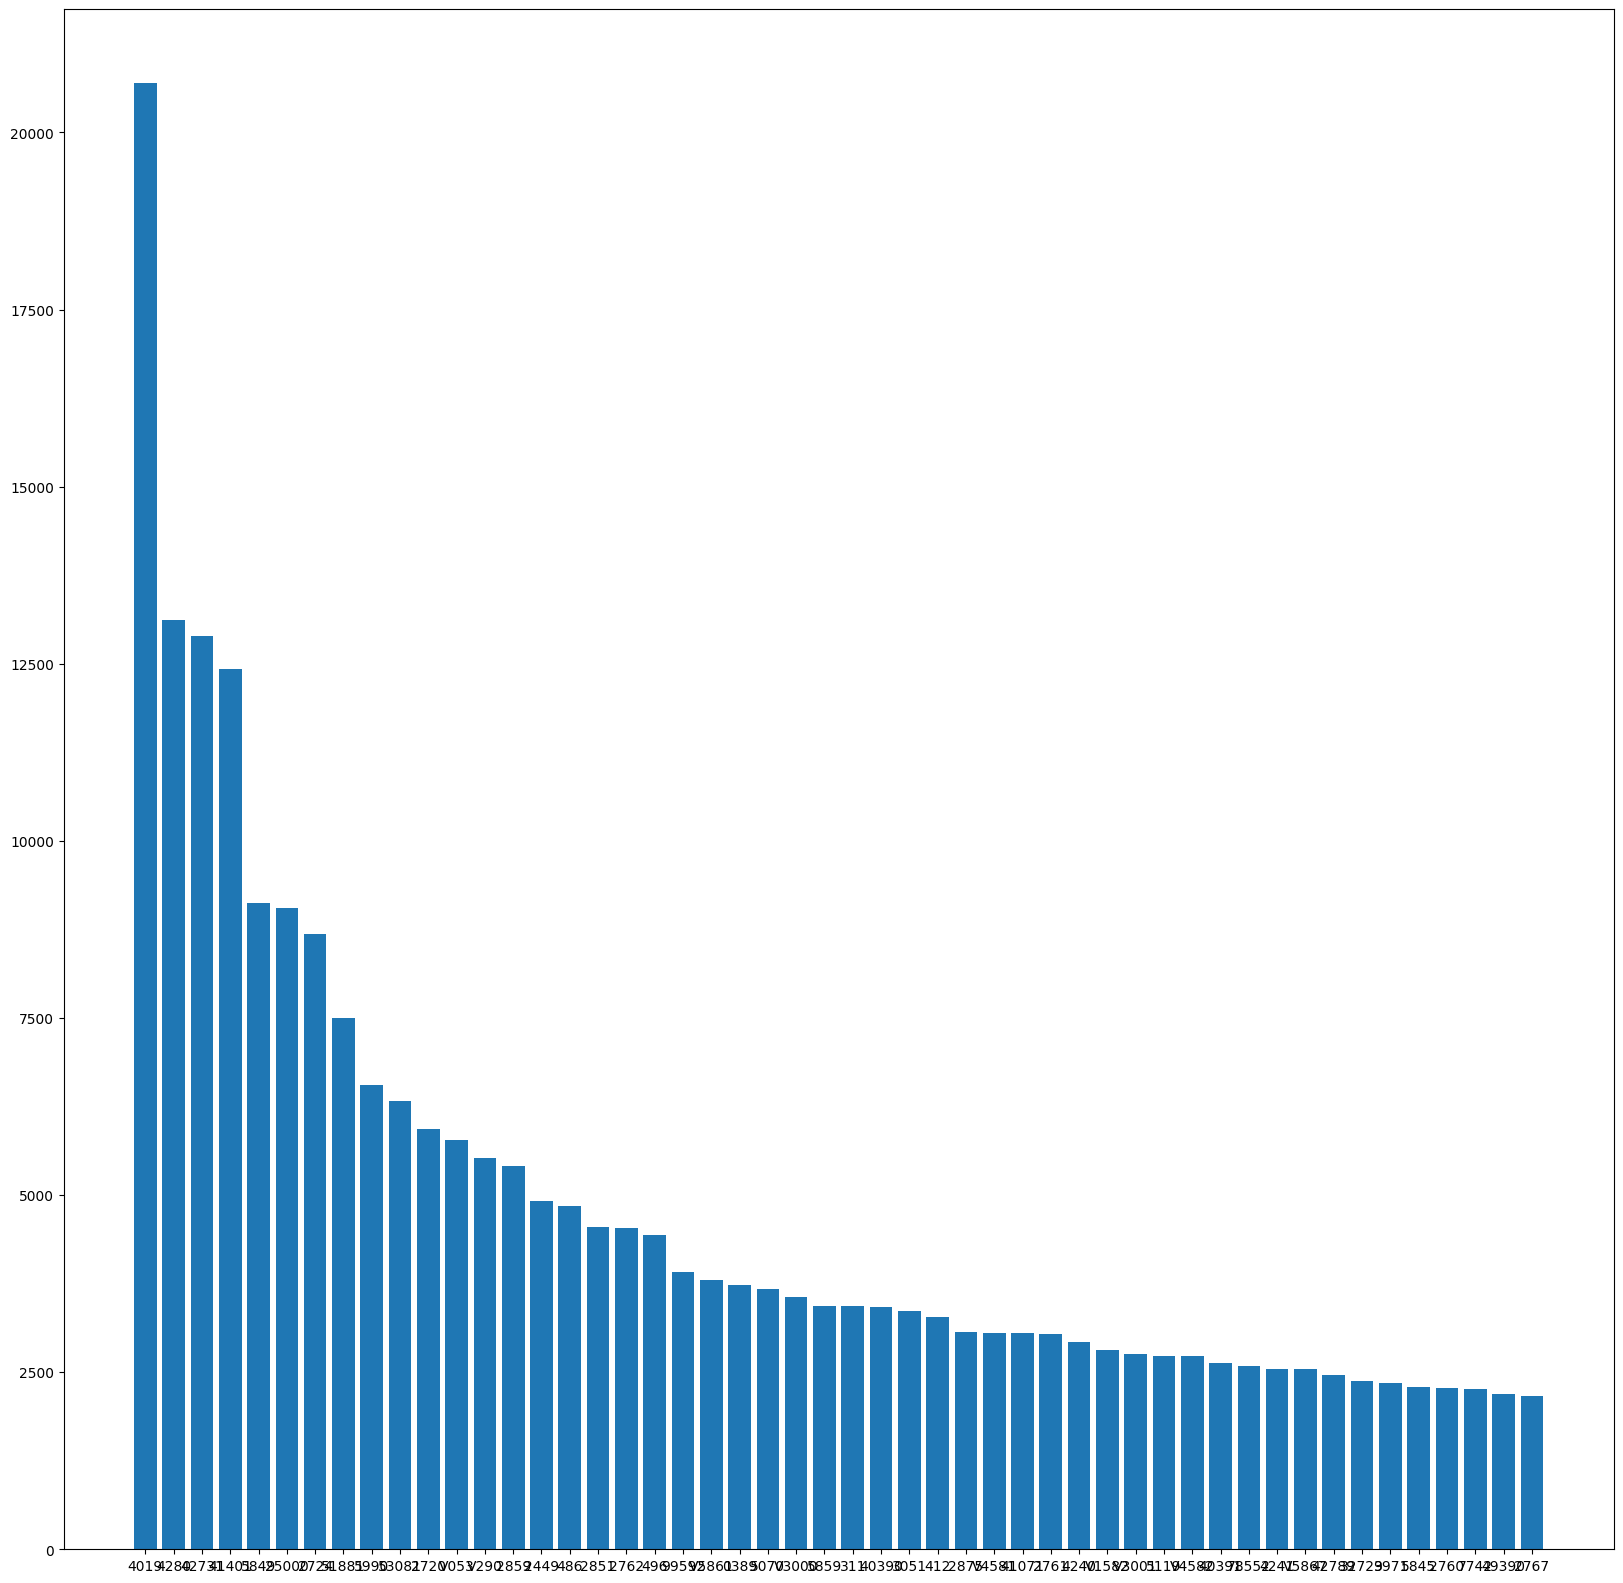

In [ ]:
plt.figure(figsize=(20,20))
plt.bar(x= df['ICD9_CODE'].value_counts(sort = True)[:50]['ICD9_CODE'], height = df['ICD9_CODE'].value_counts(sort = True)[:50]['count'])
plt.xticks(rotation = 90)
plt.show()

---

In [ ]:
# CHARTEVEENTS, NOTEEVENTS are the most expensive to load
for file in files:
    print(file)
    q1 = (
        pl.scan_csv(source = file,truncate_ragged_lines=True, low_memory=True)
        .head(n = 5)
        .collect(streaming = True)
    )

MICROBIOLOGYEVENTS.csv.gz
DRGCODES.csv.gz
PATIENTS.csv.gz
D_ITEMS.csv.gz
LABEVENTS.csv.gz
ICUSTAYS.csv.gz
PRESCRIPTIONS.csv.gz
D_LABITEMS.csv.gz
DATETIMEEVENTS.csv.gz
OUTPUTEVENTS.csv.gz
D_CPT.csv.gz
DIAGNOSES_ICD.csv.gz
D_ICD_PROCEDURES.csv.gz
TRANSFERS.csv.gz
PROCEDURES_ICD.csv.gz
INPUTEVENTS_CV.csv.gz
PROCEDUREEVENTS_MV.csv.gz
ADMISSIONS.csv.gz
CPTEVENTS.csv.gz
SERVICES.csv.gz
D_ICD_DIAGNOSES.csv.gz
CAREGIVERS.csv.gz
CALLOUT.csv.gz
INPUTEVENTS_MV.csv.gz


In [8]:
df = pd.read_csv(filepath_or_buffer='NOTEEVENTS.csv.gz')
print(df.shape)
df.head(n = 2)

/tmp/ipykernel_19822/3985783765.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath_or_buffer='NOTEEVENTS.csv.gz')


(2083180, 11)


,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT
0,174,22532,167853.0,2151-08-04,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2151-7-16**] Dischar...
1,175,13702,107527.0,2118-06-14,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2118-6-2**] Discharg...


In [35]:
pd.read_csv('ADMISSIONS.csv.gz').head(n = 5)

,ROW_ID,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,EDREGTIME,EDOUTTIME,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,HAS_CHARTEVENTS_DATA
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2196-04-09 10:06:00,2196-04-09 13:24:00,BENZODIAZEPINE OVERDOSE,0,1
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,MARRIED,WHITE,NaN,NaN,CORONARY ARTERY DISEASE\CORONARY ARTERY BYPASS...,0,1
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,ENGL,CATHOLIC,MARRIED,WHITE,NaN,NaN,BRAIN MASS,0,1
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,NaN,PROTESTANT QUAKER,SINGLE,WHITE,NaN,NaN,INTERIOR MYOCARDIAL INFARCTION,0,1
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,NaN,UNOBTAINABLE,MARRIED,WHITE,2160-11-02 01:01:00,2160-11-02 04:27:00,ACUTE CORONARY SYNDROME,0,1


In [7]:
print(q1['TEXT'][10])

Admission Date:  [**2151-7-16**]       Discharge Date:  [**2151-8-4**]


Service:
ADDENDUM:

RADIOLOGIC STUDIES:  Radiologic studies also included a chest
CT, which confirmed cavitary lesions in the left lung apex
consistent with infectious process/tuberculosis.  This also
moderate-sized left pleural effusion.

HEAD CT:  Head CT showed no intracranial hemorrhage or mass
effect, but old infarction consistent with past medical
history.

ABDOMINAL CT:  Abdominal CT showed lesions of
T10 and sacrum most likely secondary to osteoporosis. These can
be followed by repeat imaging as an outpatient.



                            [**First Name8 (NamePattern2) **] [**First Name4 (NamePattern1) 1775**] [**Last Name (NamePattern1) **], M.D.  [**MD Number(1) 1776**]

Dictated By:[**Hospital 1807**]
MEDQUIST36

D:  [**2151-8-5**]  12:11
T:  [**2151-8-5**]  12:21
JOB#:  [**Job Number 1808**]

